# Export Plot to SVG, PDF, HTML, PNG

1. [Export Using `ggsave()`](#1.-Export-Using-ggsave())

   1.1. [Export SVG to file](#1.1.-Export-SVG-to-file)

   1.2. [Export PDF to file](#1.2.-Export-PDF-to-file)

   1.3. [Export HTML to file](#1.3.-Export-HTML-to-file)

   1.4. [Export to PNG file](#1.4.-Export-to-PNG-file)

2. [Export Plot to a File or File-Like Object](#2.-Export-Plot-to-a-File-or-File-Like-Object)

   2.1. [Saving to a File](#2.1.-Saving-to-a-File)

   2.2. [Wrighting to a Stream of In-Memory Bytes](#2.2.-Wrighting-to-a-Stream-of-In-Memory-Bytes)

3. [Parameter `dpi`](#3.-Parameter-dpi)

   3.1. [72 dpi](#3.1.-72-dpi)

   3.2. [300 dpi](#3.2.-300-dpi)

In [1]:
import io

import numpy as np
import pandas as pd

from lets_plot import *

In [2]:
LetsPlot.setup_html()

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/JetBrains/lets-plot-docs/master/data/iris.csv")
print(df.shape)
df.head()

(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
p = ggplot(df) + geom_point(aes("petal_length", "petal_width", color="species"), size=5) + ggsize(600, 400)
p

## 1. Export Using `ggsave()`

The `ggsave()` function is an easy way to export plot to a file in SVG, PDF, HTML or PNG formats.

#### 1.1. Export SVG to file

In [5]:
fullpath_svg = ggsave(p, "plot.svg")

Load and display saved SVG.

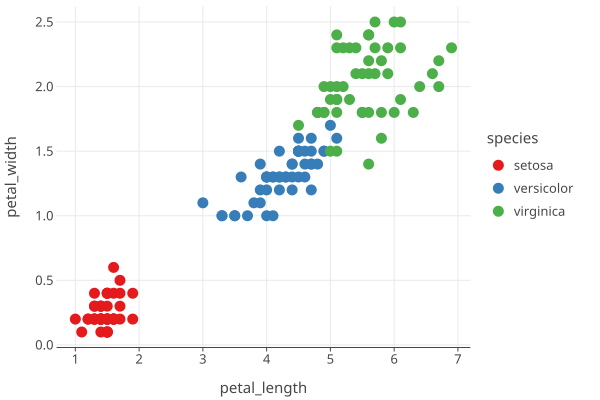

In [6]:
from IPython.display import SVG

SVG(filename=fullpath_svg)

#### 1.2. Export PDF to file

In [7]:
fullpath_pdf = ggsave(p, "plot.pdf")

Load and display saved PDF.

In [8]:
from os import getcwd
from IPython.display import IFrame

IFrame(fullpath_pdf.replace(getcwd(), "."), width=600, height=400)

#### 1.3. Export HTML to file

By default, when exporting HTML, `ggsave` wraps the HTML of the plot in an `iframe` that matches the size of the plot.

In [9]:
fullpath_html = ggsave(p, "plot.html")

Load and display saved HTML.

In [10]:
from IPython.display import HTML

HTML(filename=fullpath_html)

Use the `iframe=False` option to only export the HTML of the plot, without adding an `iframe`.

In [11]:
fullpath_no_iframe = ggsave(p, "no_iframe_plot.html", iframe=False)

In [12]:
HTML(filename=fullpath_no_iframe)

#### 1.4. Export to PNG file

To export plot to a PNG file you should install the [CairoSVG](https://pypi.org/project/CairoSVG/) library to your Python environment.

To save plot as a PNG file use a filename that have "png" extension. 

In [13]:
fullpath_png = ggsave(p, "plot.png")

Load and display saved PNG.

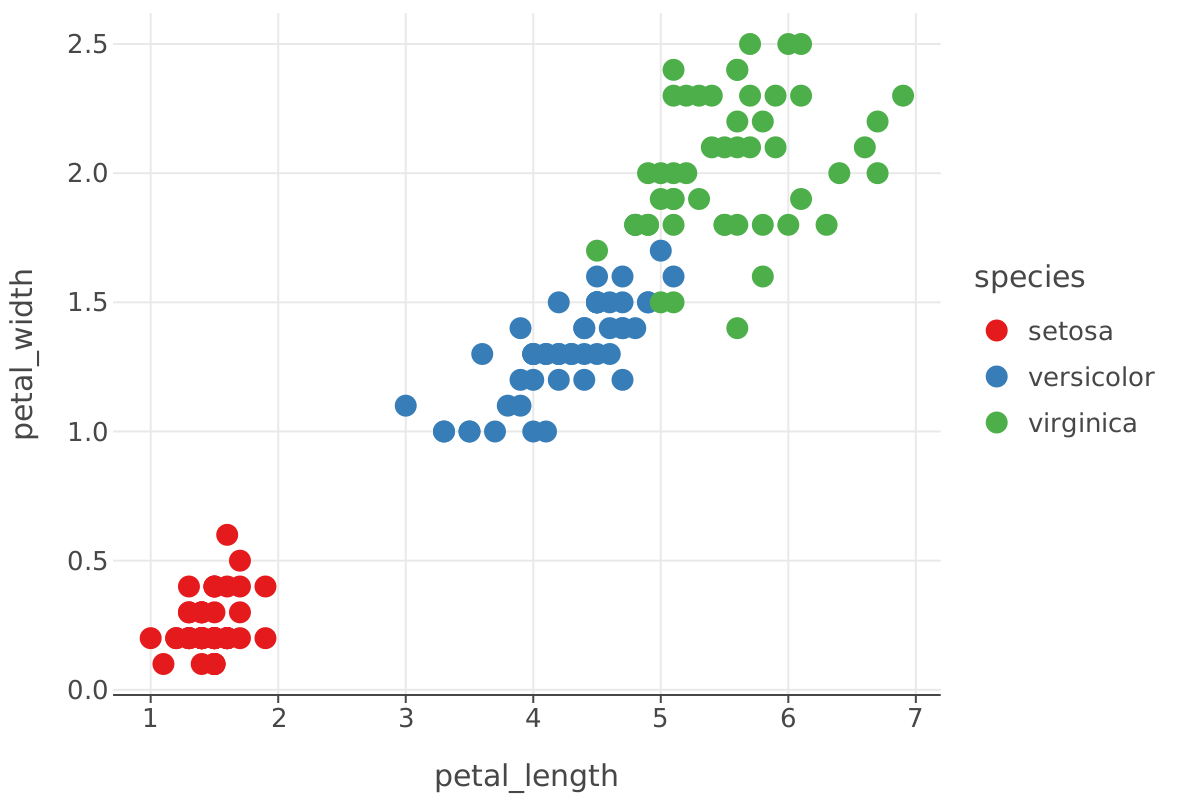

In [14]:
from IPython.display import Image

Image(filename=fullpath_png, width=600, height=400)

## 2. Export Plot to a File or File-Like Object

You can export figure created by `ggplot()` or `gggrid()` functions <br>
to a vector or raster format using the following methods: 
- `to_svg(path)`
- `to_html(path, iframe)`
- `to_png(path, scale)`
- `to_pdf(path, scale)`

To save plot to a file on disc, specify the file' pathname in `path`. <br>
To stream plot image to a file-like object, supply such object in the `path` parameter instead of a pathname.

#### 2.1. Saving to a File

In [15]:
path = p.to_svg("lets-plot-images/to_svg_plot.svg")

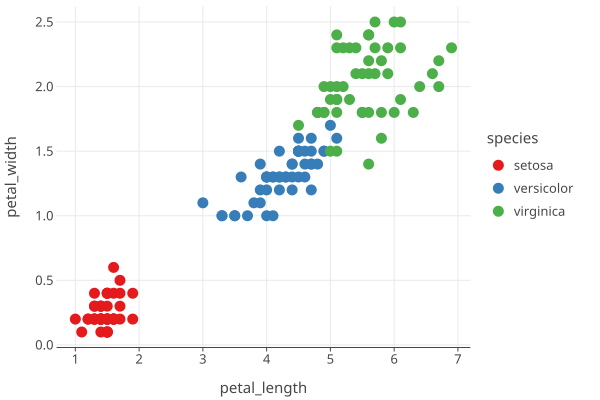

In [16]:
SVG(path)

#### 2.2. Wrighting to a Stream of In-Memory Bytes

In [17]:
stream = io.BytesIO()

p.to_svg(stream)

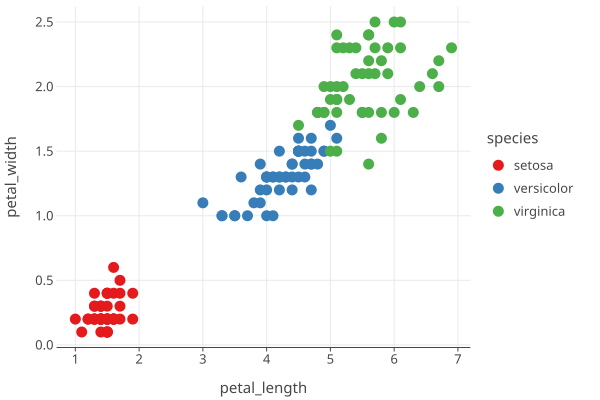

In [18]:
SVG(stream.getvalue())

## 3. Parameter `dpi`

Parameters `dpi`, `w`, `h` and `unit` can be used to configure export to a raster image with required physical metrics. Aspect ratio must be maintained manually between `ggsize()` and `ggsave()`. Please note that using these parameters will disable the `scale` parameter.

#### 3.1. 72 dpi

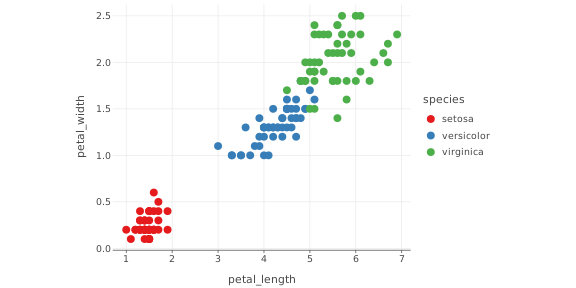

In [19]:
img_72 = ggsave(p, "72dpi_plot.png", w=8, h=4, unit='in', dpi=72)
Image(filename=img_72, width=800, height=600)

#### 3.2. 300 dpi

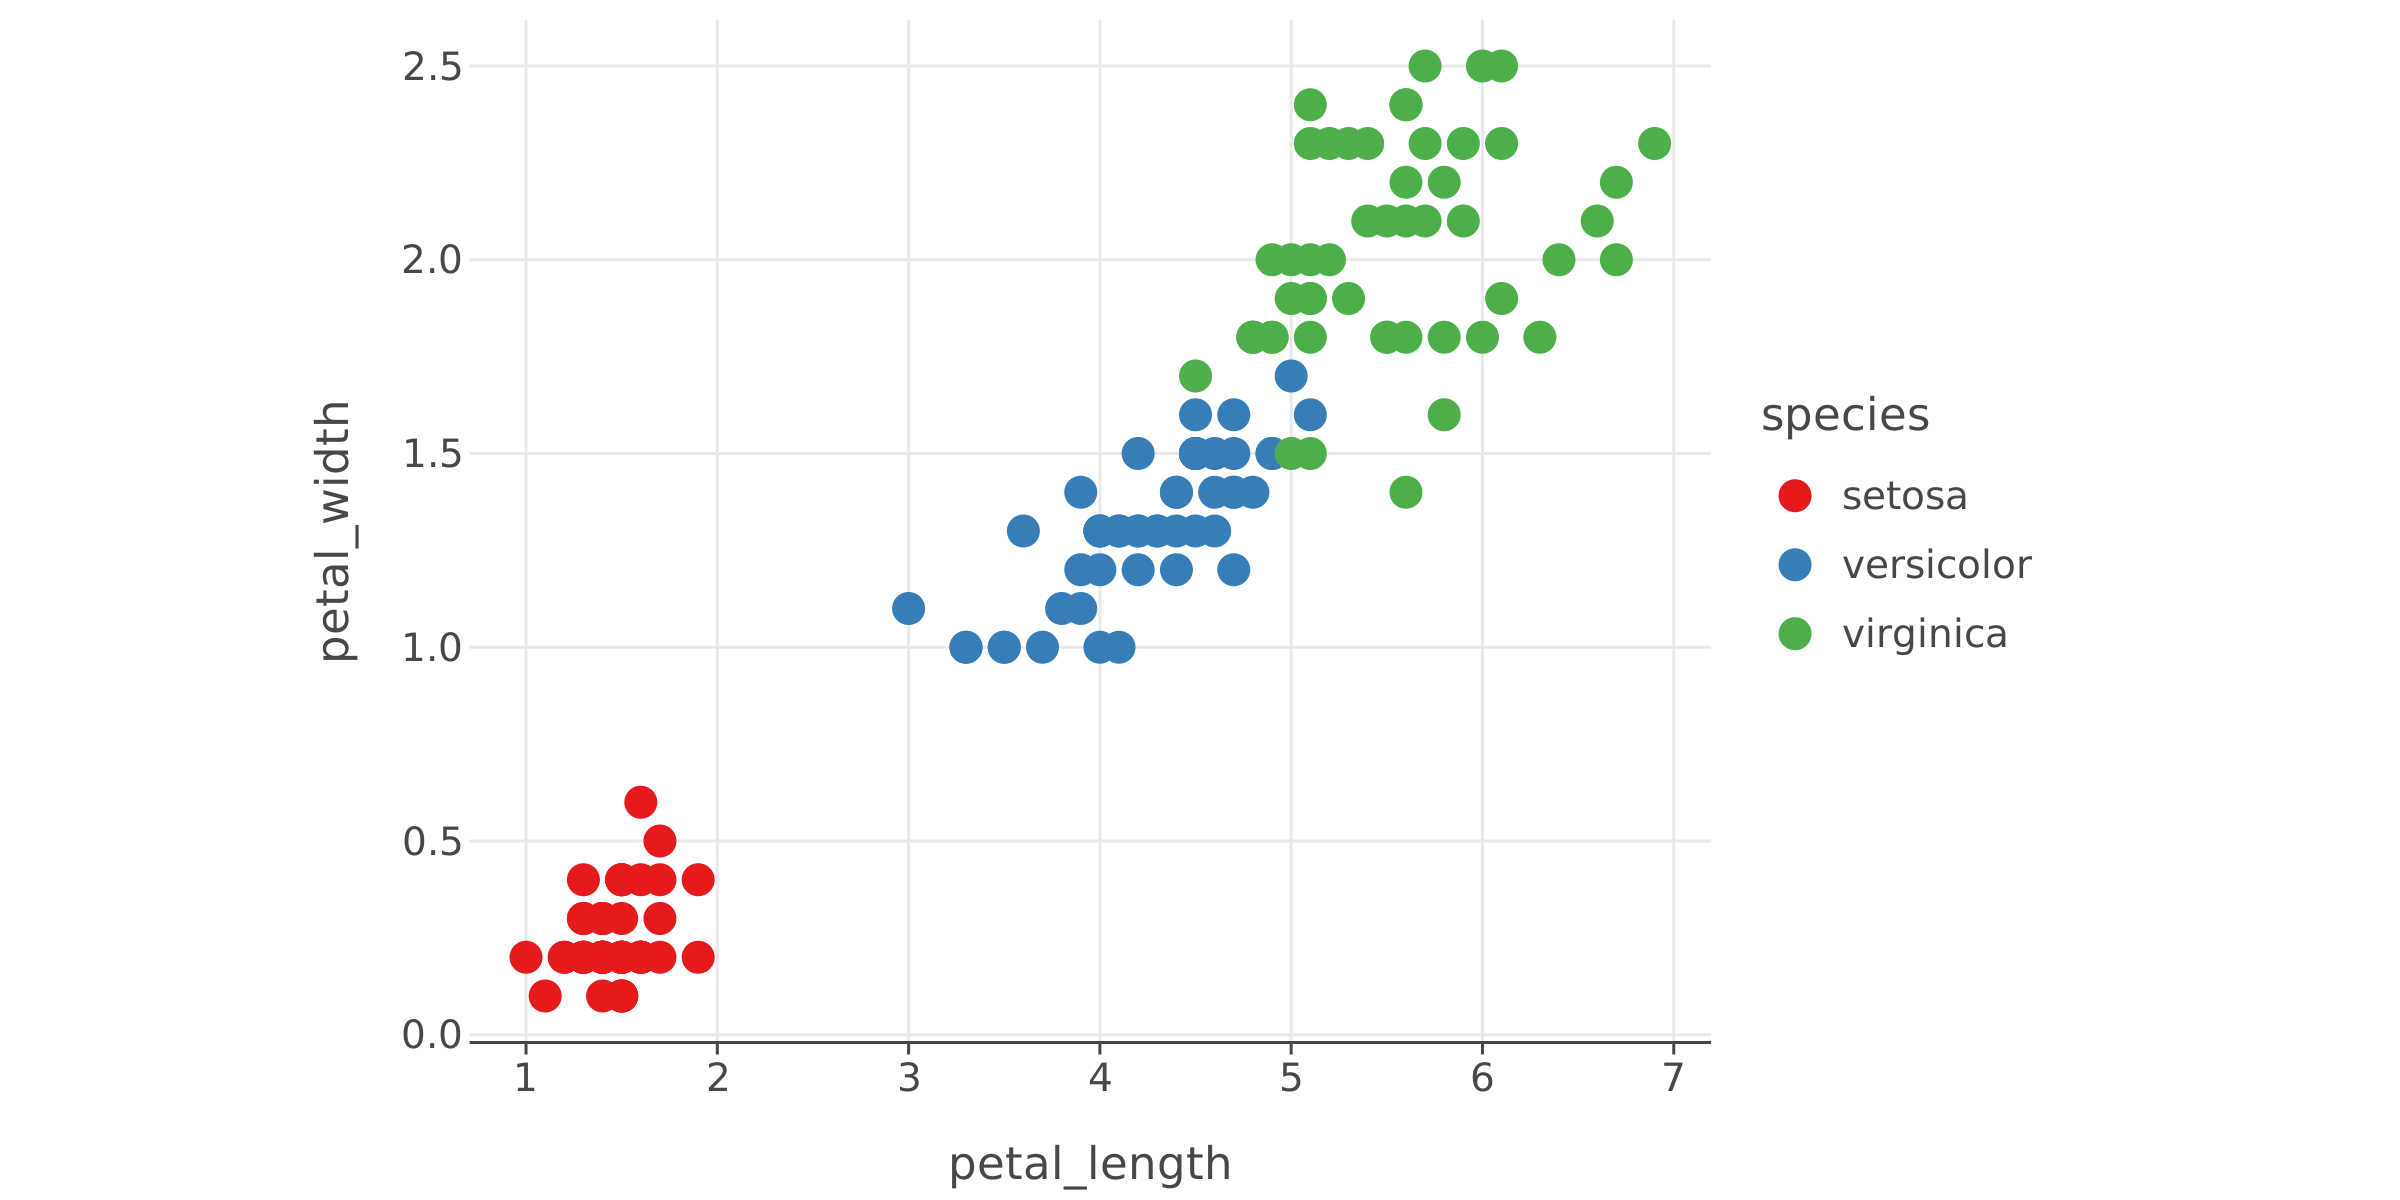

In [20]:
img_300 = ggsave(p, "300dpi_plot.png", w=8, h=4, unit='in', dpi=300)
Image(filename=img_300, width=800, height=600)